In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krupalpatel07/bitcoin-market-microstructure-dataset/BTC-USD.csv


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

df = pd.read_csv("/kaggle/input/datasets/krupalpatel07/bitcoin-market-microstructure-dataset/BTC-USD.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

In [14]:
# ==============================
# Feature Engineering
# ==============================
df["Return"] = df["Close"].pct_change()

df["Volatility"] = df["Return"].rolling(30).std() * np.sqrt(365)

df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

df["Cumulative"] = (1 + df["Return"]).cumprod()

rolling_max = df["Cumulative"].cummax()

df["Drawdown"] = (df["Cumulative"] - rolling_max) / rolling_max


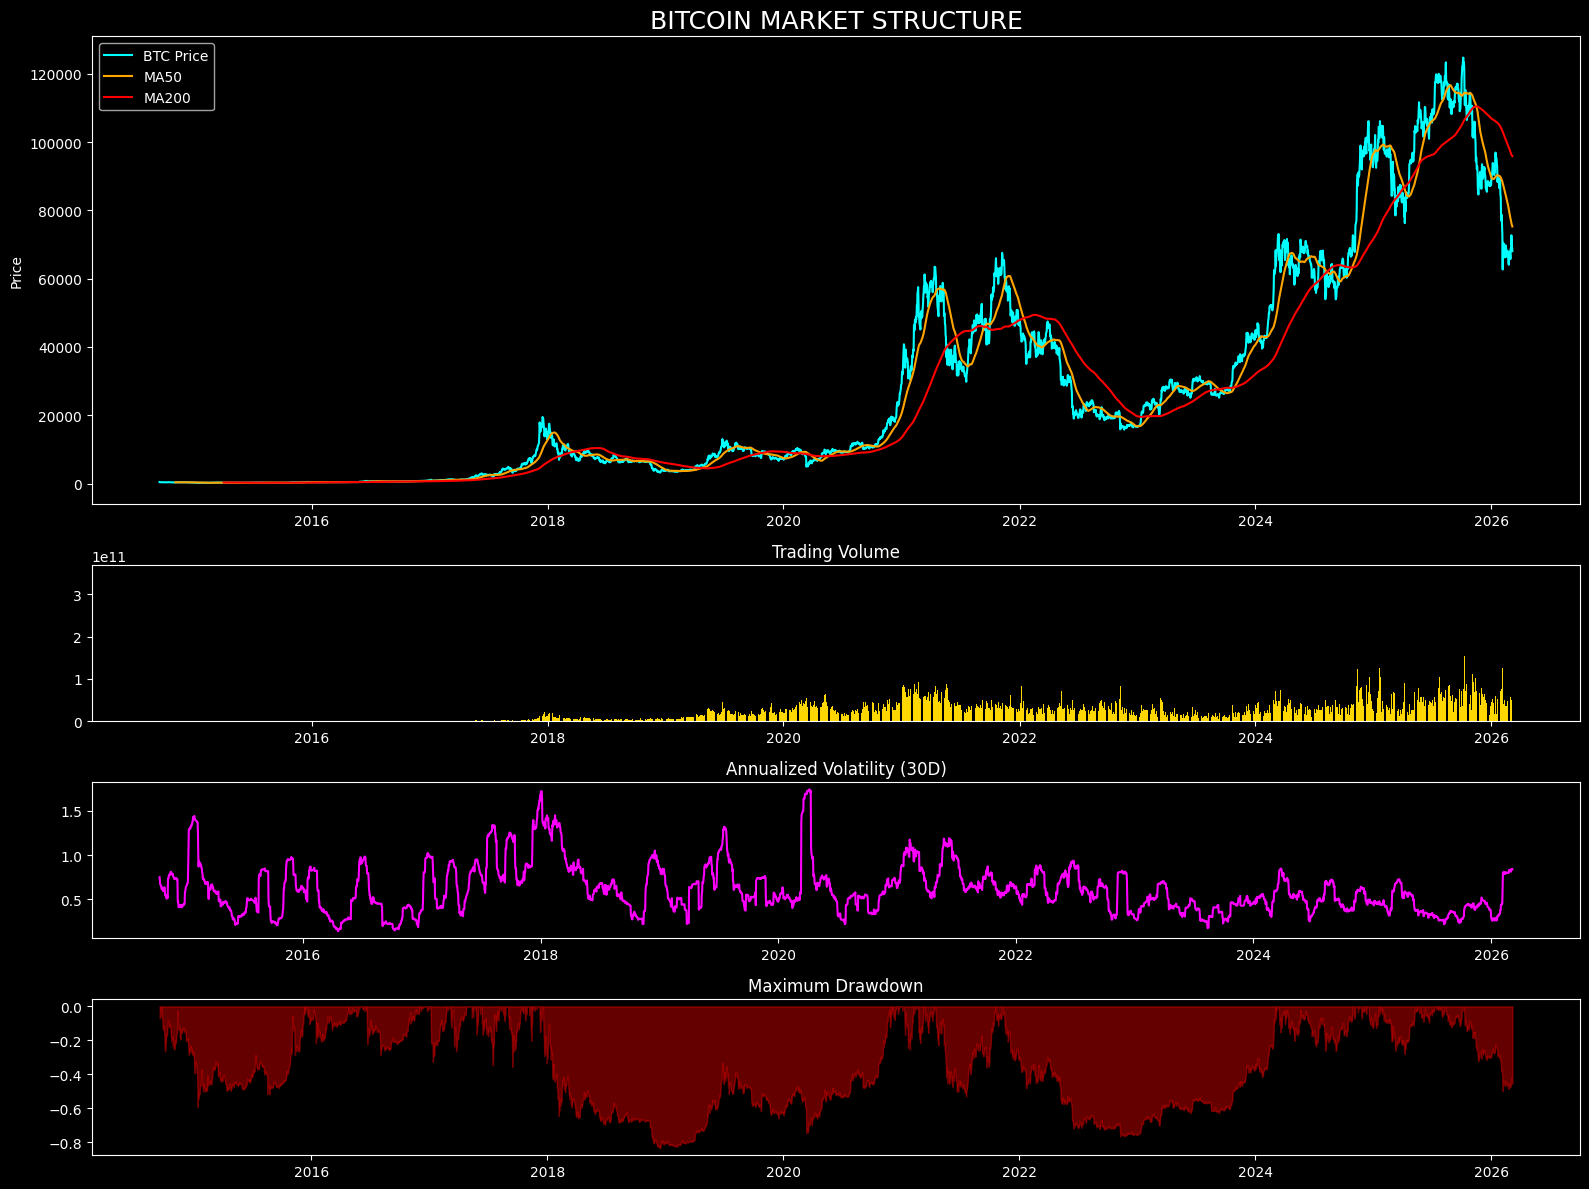

In [15]:
# ==============================
# CREATE IMAGE
# ============================== 

fig = plt.figure(figsize=(16,12))

gs = fig.add_gridspec(4,1, height_ratios=[3,1,1,1])

# --------------------------------
# PRICE PANEL
# --------------------------------

ax1 = fig.add_subplot(gs[0])

ax1.plot(df.index, df["Close"], color="cyan", linewidth=1.5, label="BTC Price")

ax1.plot(df.index, df["MA50"], color="orange", label="MA50")

ax1.plot(df.index, df["MA200"], color="red", label="MA200")

ax1.set_title("BITCOIN MARKET STRUCTURE", fontsize=18)

ax1.set_ylabel("Price")

ax1.legend()


# --------------------------------
# VOLUME PANEL
# --------------------------------

ax2 = fig.add_subplot(gs[1])

ax2.bar(df.index, df["Volume"], color="gold")

ax2.set_title("Trading Volume")


# --------------------------------
# VOLATILITY PANEL
# --------------------------------

ax3 = fig.add_subplot(gs[2])

ax3.plot(df.index, df["Volatility"], color="magenta")

ax3.set_title("Annualized Volatility (30D)")


# --------------------------------
# DRAWDOWN PANEL
# --------------------------------

ax4 = fig.add_subplot(gs[3])

ax4.fill_between(df.index, df["Drawdown"], 0, color="red", alpha=0.4)

ax4.set_title("Maximum Drawdown")

plt.tight_layout()

plt.savefig("bitcoin_dashboard.png", dpi=300)

plt.show()

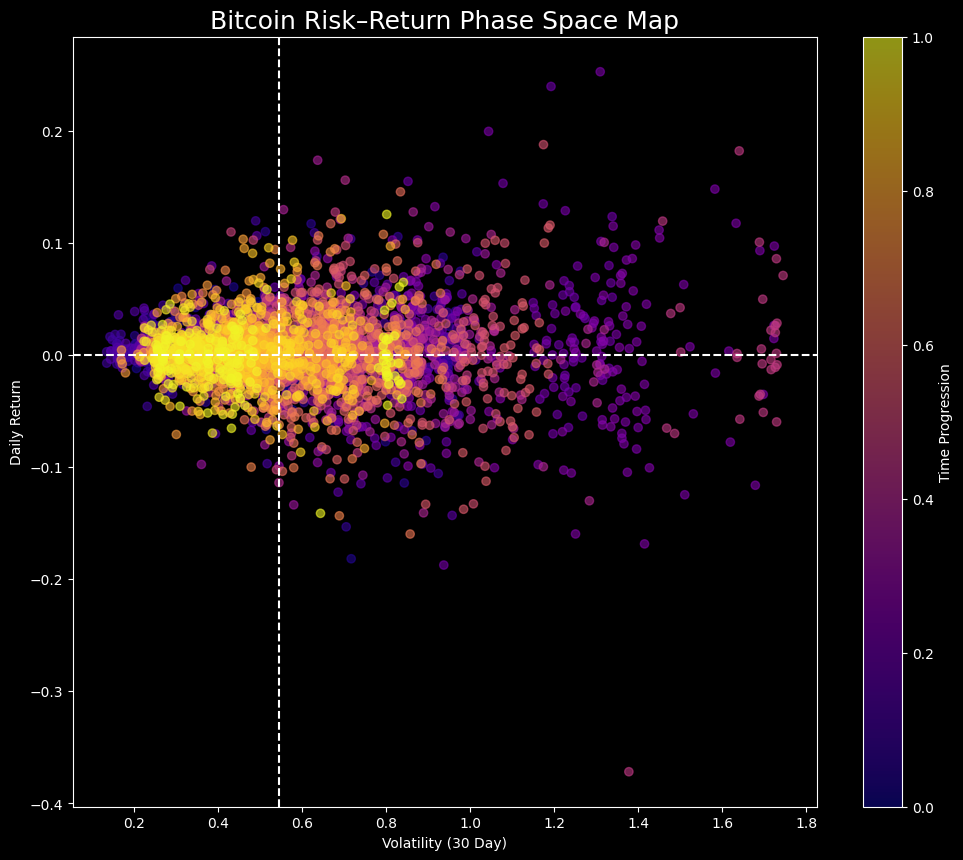

In [16]:
df = df.dropna()

# Normalize time for coloring
df["Time_Index"] = np.linspace(0,1,len(df))

# ---------------------------
# Risk Return Space
# ---------------------------

plt.figure(figsize=(12,10))

scatter = plt.scatter(
    df["Volatility"],
    df["Return"],
    c=df["Time_Index"],
    cmap="plasma",
    alpha=0.6
)

plt.colorbar(scatter, label="Time Progression")

plt.title("Bitcoin Risk–Return Phase Space Map", fontsize=18)

plt.xlabel("Volatility (30 Day)")
plt.ylabel("Daily Return")

plt.axhline(0, linestyle="--")
plt.axvline(df["Volatility"].median(), linestyle="--")

plt.show()

### Market State Meaning
* Low vol + positive returns =>	steady bull
* High vol + negative returns =>	crash regime
* High vol + mixed returns =>	panic
* Low vol + flat returns =>   consolidation

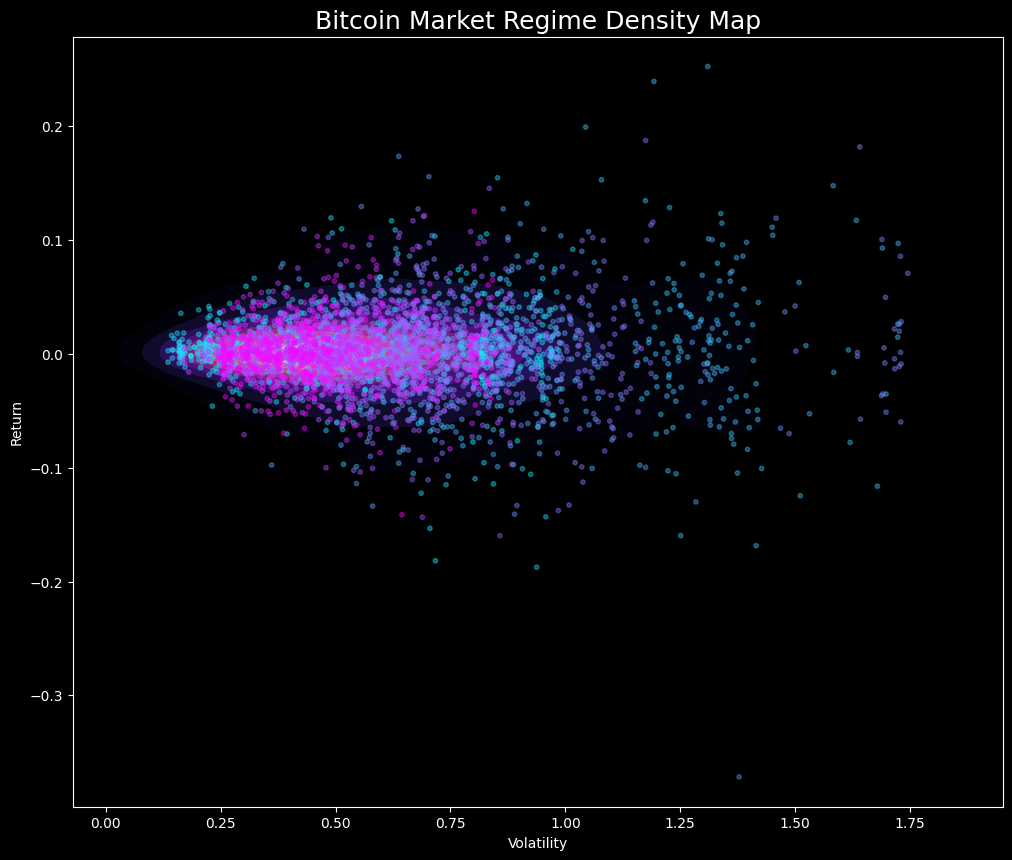

In [17]:
plt.figure(figsize=(12,10))

sns.kdeplot(
    x=df["Volatility"],
    y=df["Return"],
    cmap="magma",
    fill=True,
    thresh=0.05
)

plt.scatter(
    df["Volatility"],
    df["Return"],
    c=df["Time_Index"],
    cmap="cool",
    s=10,
    alpha=0.4
)

plt.title("Bitcoin Market Regime Density Map", fontsize=18)

plt.xlabel("Volatility")
plt.ylabel("Return")

plt.show()

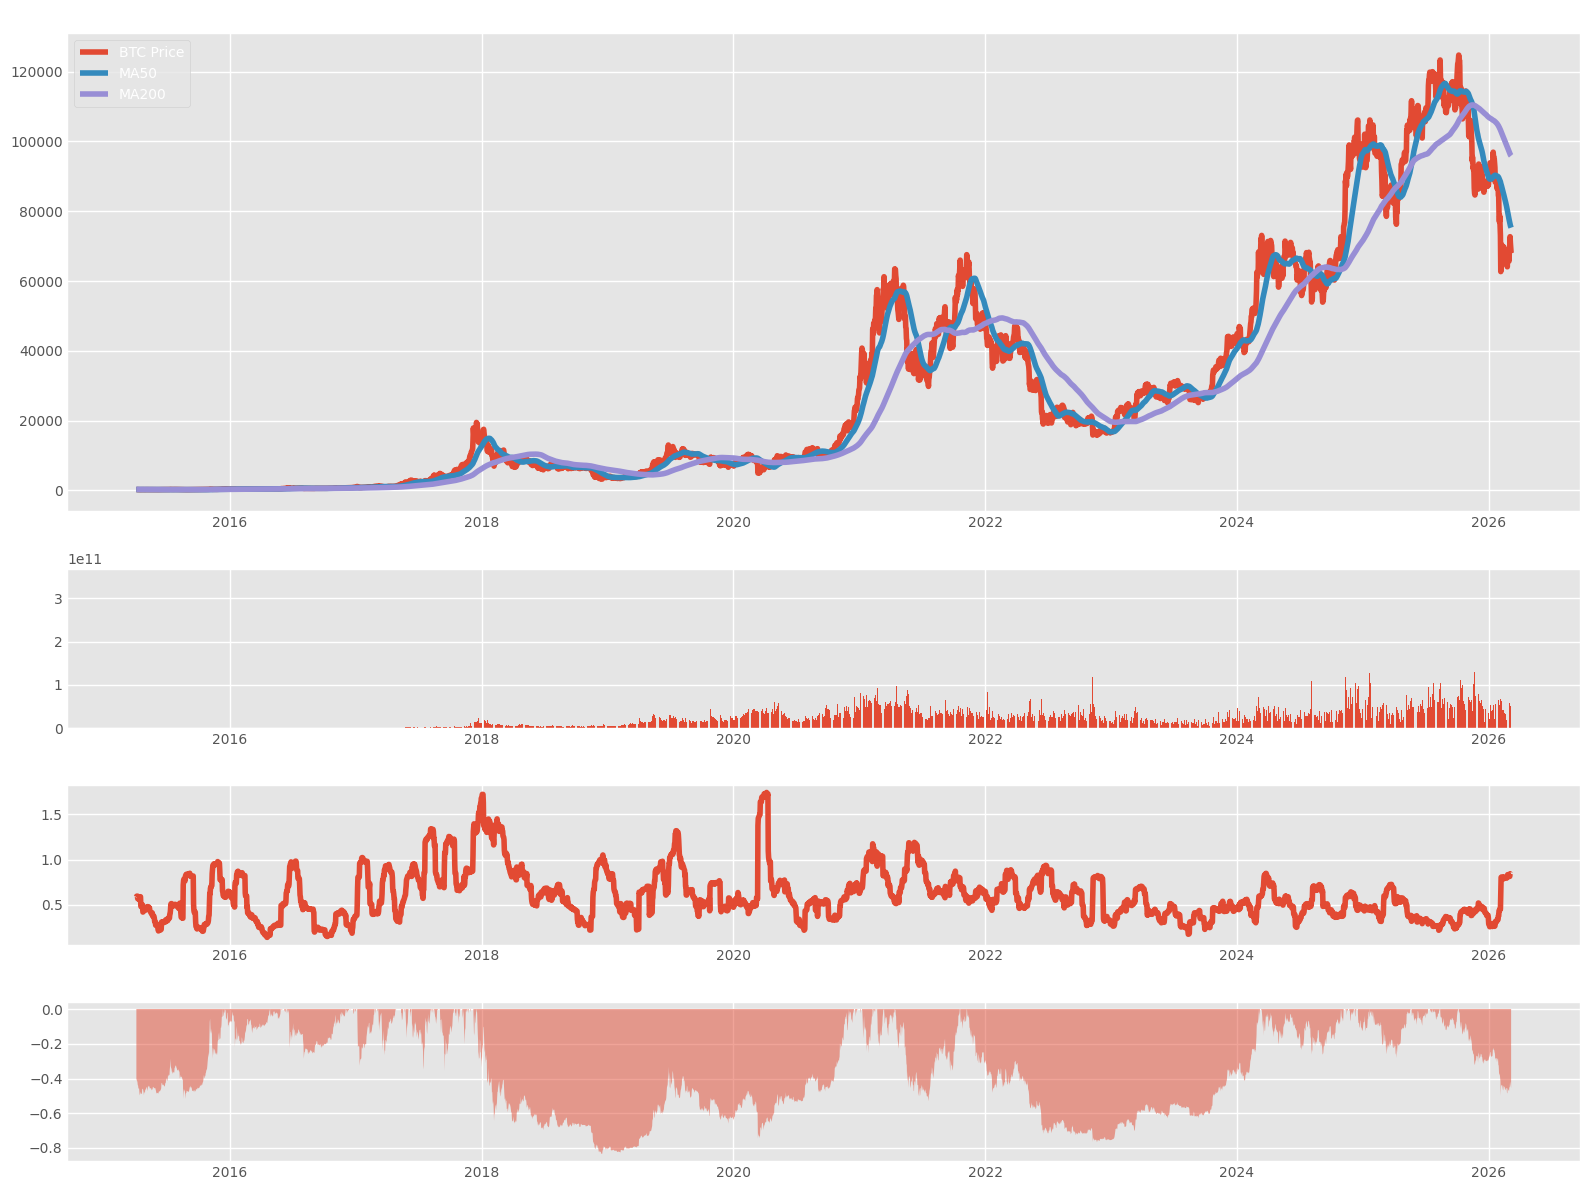

In [22]:

# a terminal screen
fig = plt.figure(figsize=(16,12))
grid = fig.add_gridspec(4,1,height_ratios=[3,1,1,1])

# Panel 1: Price
ax1 = fig.add_subplot(grid[0])
ax1.plot(df.index, df["Close"], label="BTC Price")
ax1.plot(df.index, df["MA50"], label="MA50")
ax1.plot(df.index, df["MA200"], label="MA200")
ax1.set_title("Bitcoin Market Dashboard")
ax1.legend()

# Panel 2: Volume
ax2 = fig.add_subplot(grid[1], sharex=ax1)
ax2.bar(df.index, df["Volume"])
ax2.set_title("Volume")

# Panel 3: Volatility
ax3 = fig.add_subplot(grid[2], sharex=ax1)
ax3.plot(df.index, df["Volatility"])
ax3.set_title("30-Day Annualized Volatility")

# Panel 4: Drawdown
ax4 = fig.add_subplot(grid[3], sharex=ax1)
ax4.fill_between(df.index, df["Drawdown"],0,alpha=0.5)
ax4.set_title("Maximum Drawdown")

plt.tight_layout()
plt.savefig("bitcoin_dashboard.png", dpi=300)
plt.show()